# Examine Boreal Height validation with LVIS 30m  

--Note-- update this with new CSV derived from new height maps:  
 + `v2.1` : /projects/shared-buckets/montesano/DPS_tile_lists/BOREAL_MAP/dev_v1.5/Ht_H30_2020/full_run_no_uncert/HT_tindex_master.csv  
 + `v2.2` : /projects/shared-buckets/montesano/DPS_tile_lists/BOREAL_MAP/dev_v1.5/Ht_S1H30_2020/full_run_no_uncert/HT_tindex_master.csv  

08 January 2025
Paul Montesano, PhD

  Contributors | Project | Affiliation | 
| ---------------- | ---------------- | ---------------- |
| Paul Montesano paul.m.montesano@nasa.gov |  multiple | NASA Goddard Space Flight Center |

In [1]:
library(tidyverse)
library(sf)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Linking to GEOS 3.12.1, GDAL 3.8.3, PROJ 9.3.1; sf_use_s2() is TRUE



In [2]:
library(viridis)
library(patchwork)

Loading required package: viridisLite



In [3]:
df = read.csv('/projects/shared-buckets/tonyumd/gridded_ht_validation_file.csv')

In [4]:
dim(df)

[1] 20095347        8

In [5]:
df$slope_class = cut(df$LVIS.slope, breaks=c(0, 2, 4, 6, Inf), labels = c("0-2", "2-4", "4-6", ">6"), include.lowest = TRUE)
cover_classes = c("0-10%", "11-20%", "21-30%", "31-40%", ">41%")
df$cover_class = factor(cut(df$LVIS.Cover, breaks=c(0, 1000., 2000., 3000., 4000., 10000.), labels = cover_classes, include.lowest = TRUE), levels = cover_classes)

In [19]:
height_classes = c("0-2m", ">2-4m", ">4-6m", ">6-8", ">8-10", ">10")
df$height_class = factor(cut(df$LVIS.Height, breaks=c(0, 2, 4, 6, 8, 10, Inf), labels = height_classes, include.lowest = TRUE), levels = height_classes)

In [16]:
tail(df)

,X.1,X,LVIS.Height,LVIS.slope,LVIS.Cover,Gridded.ATL08.Height,Lon,Lat,slope_class,cover_class,residuals,height_class
,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<fct>
20095342,20555288,20555,5.2051472,3.079375,1964.05116,3.938952,-120.7773,45.05412,2-4,11-20%,-1.2661955,>4-6m
20095343,16204351,16204,0.6103117,4.737404,39.93067,1.660302,-120.7832,45.06024,4-6,0-10%,1.0499905,0-2m
20095344,45820234,46188,1.2144747,8.618620,173.63973,3.419375,-120.6832,45.01663,>6,0-10%,2.2049005,0-2m
20095345,40828228,40829,2.0125567,31.739902,679.59311,4.135951,-120.6762,45.02428,>6,0-10%,2.1233944,>2-4m
20095346,22159277,22159,0.7446033,2.797757,55.99003,1.650474,-120.7762,45.05182,2-4,0-10%,0.9058706,0-2m
20095347,29369268,29369,1.4593656,7.446260,365.92635,1.808971,-120.6993,45.04111,>6,0-10%,0.3496051,0-2m


In [7]:
df$residuals = df$Gridded.ATL08.Height - df$LVIS.Height

In [8]:
library(plyr)
lm_eqn = function(df){
      y=df[,1]
      x=df[,2]
      m = lm(y ~ x, df);

      eq <- substitute(italic(y) == a + b %.% italic(x)*","~~italic(r)^2~"="~r2,
           list(a = format(coef(m)[1], digits = 2),
                b = format(coef(m)[2], digits = 2),
               r2 = format(summary(m)$r.squared, digits = 3)))
      int = format(coef(m)[1], digits = 2)
      slope = format(coef(m)[2], digits = 2)
      # https://stackoverflow.com/questions/43123462/how-to-obtain-rmse-out-of-lm-result

      rss   <- c(crossprod(m$residuals))
      mse   <- rss / length(m$residuals)

      rmse  <- format(sqrt(mse),dig=2)
      sig2  <- format(rss / m$df.residual, dig=2) # Pearson estimated residual variance (as returned by summary.lm):
      n     <- nobs(m)
      r2    <- format(summary(m)$r.squared, dig = 2)
      mae   <- format(mean(abs(m$residuals)), dig = 2)
      mape  <- format(mean(abs((m$residuals)/y))*100, dig=2)  #https://stats.stackexchange.com/questions/299712/what-are-the-shortcomings-of-the-mean-absolute-percentage-error-mape

      #return(as.character(as.expression(eq)))
      return(data.frame(cbind(int, slope, r2, rmse, sig2, n, mae, mape)))
  }

------------------------------------------------------------------------------

You have loaded plyr after dplyr - this is likely to cause problems.
If you need functions from both plyr and dplyr, please load plyr first, then dplyr:
library(plyr); library(dplyr)

------------------------------------------------------------------------------


Attaching package: ‘plyr’


The following objects are masked from ‘package:dplyr’:

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


The following object is masked from ‘package:purrr’:

    compact




In [12]:
library(RColorBrewer)
pal_rev_spectral9 = rev(brewer.pal(9,"Spectral"))

In [13]:
# Create the equation labels for the two groups
df_eq <- ddply(df %>% dplyr::select(Gridded.ATL08.Height, LVIS.Height, cover_class, slope_class), 
               .(cover_class, slope_class), 
               c("lm_eqn") 
              )

In [14]:
MAX_HT = 30
val_plot_geom_list = list(
        ggtitle("Boreal forest height: Boreal vs LVIS"),
        #scale_fill_gradientn( labels = my_breaks, breaks = my_breaks, limits = c(min(my_breaks),max(my_breaks)+3000),colours=pal_rev_spectral9, trans = "log", name='# obs.'),
        scale_fill_gradientn( labels = c(1e0, 1e1, 1e2, 1e3, 1e4,1e5), breaks = c(1e0, 1e1, 1e2, 1e3, 1e4,1e5), limits = c(1,3e5), colours=pal_rev_spectral9, trans = "log", name='# obs.'),
        guides(colour = guide_legend(override.aes = list(alpha = 1))),
        #geom_vline(xintercept = 0, linetype = "dashed"),
        #geom_hline(yintercept = 0, linetype = "dashed"),
        geom_abline(intercept = 0, slope = 1, linewidth= 0.25),
        stat_smooth(method = "lm", col = "black", linetype = "dashed", se = TRUE),
        theme_minimal()+
        theme(axis.text = element_text(size = 6)),
        coord_fixed(),
        scale_y_continuous(breaks = seq(0,MAX_HT-5,5), limits = c(0,MAX_HT)),
        scale_x_continuous(breaks = seq(0,MAX_HT-5,5), limits = c(0,MAX_HT)),
        geom_label(data=df_eq, aes(x = 10, y = MAX_HT-5,label=paste("r^2 ==", r2,sep='')), parse = TRUE, hjust=0, vjust=0, size=5, color = "black", fill="white", label.padding=unit(0.2,"lines")),
        geom_label(data=df_eq, aes(x = 10, y = MAX_HT-9,label=paste("rmse ==", rmse,sep='')), parse = TRUE, hjust=0, vjust=0, size=5, color = "black", fill="white", label.padding=unit(0.2,"lines")),
        geom_label(data=df_eq, aes(x = 10, y = MAX_HT-13,label=paste("bias ==", int,sep='')), parse = TRUE, hjust=0, vjust=0, size=5, color = "black", fill="white", label.padding=unit(0.2,"lines")),
        geom_label(data=df_eq, aes(x = 10, y = MAX_HT-17,label=paste("slope ==", slope,sep='')),parse = TRUE, hjust=0, vjust=0, size=5, color = "black", fill="white", label.padding=unit(0.2,"lines"))
)
  

Warning message:
“Removed 78891 rows containing non-finite values (`stat_bin2d()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 78891 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 565 rows containing missing values (`geom_tile()`).”
Warning message:
“Removed 29 rows containing missing values (`geom_smooth()`).”


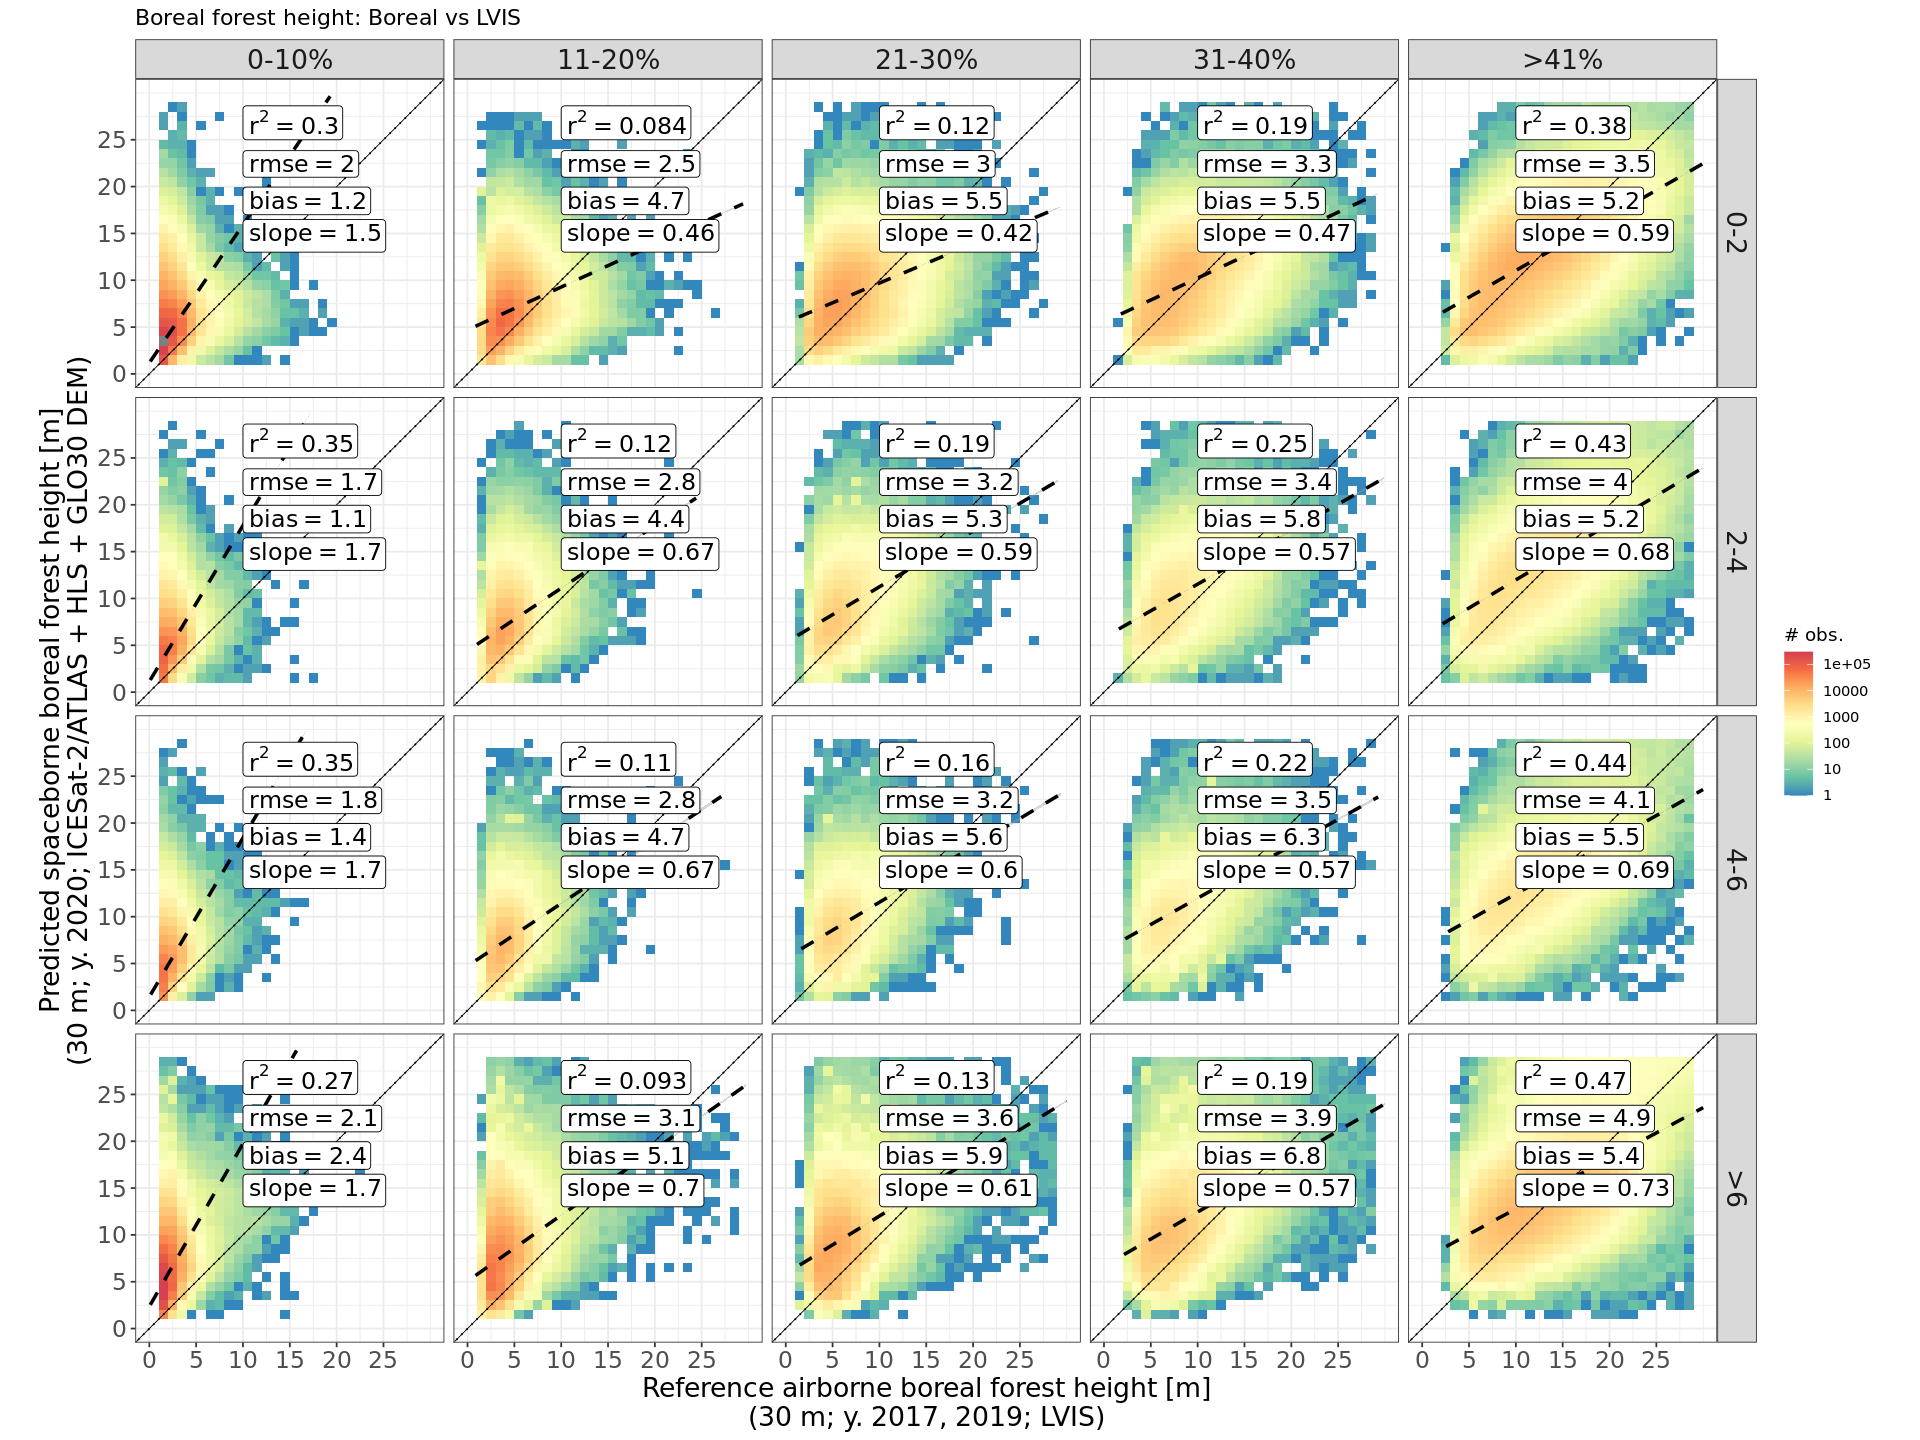

In [118]:
options(repr.plot.width = 16, repr.plot.height = 12)

ggplot(df, aes(x=LVIS.Height, y=Gridded.ATL08.Height)) +
    geom_bin2d() +
    geom_abline(linetype = 'dotted') +
    #scale_fill_viridis(trans = 'log', breaks = c(1e0, 1e1, 1e2, 1e3, 1e4,1e5), option = 'plasma') + 
    val_plot_geom_list +
    facet_grid("slope_class~cover_class") +
    theme_bw() +
    theme(
        strip.text = element_text(size=16),
        axis.text = element_text(size=14),
        axis.title = element_text(size=16)
        ) +
    labs(y = 'Predicted spaceborne boreal forest height [m]\n(30 m; y. 2020; ICESat-2/ATLAS + HLS + GLO30 DEM)',
         x = 'Reference airborne boreal forest height [m]\n(30 m; y. 2017, 2019; LVIS)')

In [119]:
# Create the equation labels for the 1 group
df_eq <- ddply(df %>% dplyr::select(Gridded.ATL08.Height, LVIS.Height, cover_class, slope_class), 
               .(cover_class), 
               c("lm_eqn") 
              )

In [121]:
MAX_HT = 30
val_plot_geom_list = list(
        ggtitle("Boreal forest height: Boreal vs LVIS"),
        #scale_fill_gradientn( labels = my_breaks, breaks = my_breaks, limits = c(min(my_breaks),max(my_breaks)+3000),colours=pal_rev_spectral9, trans = "log", name='# obs.'),
        scale_fill_gradientn( labels = c(1e0, 1e1, 1e2, 1e3, 1e4,1e5), breaks = c(1e0, 1e1, 1e2, 1e3, 1e4,1e5), limits = c(1,3e5), colours=pal_rev_spectral9, trans = "log", name='# obs.'),
        guides(colour = guide_legend(override.aes = list(alpha = 1))),
        #geom_vline(xintercept = 0, linetype = "dashed"),
        #geom_hline(yintercept = 0, linetype = "dashed"),
        geom_abline(intercept = 0, slope = 1, linewidth= 0.25),
        stat_smooth(method = "lm", col = "black", linetype = "dashed", se = TRUE),
        theme_minimal()+
        theme(axis.text = element_text(size = 6)),
        coord_fixed(),
        scale_y_continuous(breaks = seq(0,MAX_HT-5,5), limits = c(0,MAX_HT)),
        scale_x_continuous(breaks = seq(0,MAX_HT-5,5), limits = c(0,MAX_HT)),
        geom_label(data=df_eq, aes(x = 10, y = MAX_HT-5,label=paste("r^2 ==", r2,sep='')), parse = TRUE, hjust=0, vjust=0, size=5, color = "black", fill="white", label.padding=unit(0.2,"lines")),
        geom_label(data=df_eq, aes(x = 10, y = MAX_HT-9,label=paste("rmse ==", rmse,sep='')), parse = TRUE, hjust=0, vjust=0, size=5, color = "black", fill="white", label.padding=unit(0.2,"lines")),
        geom_label(data=df_eq, aes(x = 10, y = MAX_HT-13,label=paste("bias ==", int,sep='')), parse = TRUE, hjust=0, vjust=0, size=5, color = "black", fill="white", label.padding=unit(0.2,"lines")),
        geom_label(data=df_eq, aes(x = 10, y = MAX_HT-17,label=paste("slope ==", slope,sep='')),parse = TRUE, hjust=0, vjust=0, size=5, color = "black", fill="white", label.padding=unit(0.2,"lines"))
)
  

Warning message:
“Removed 78891 rows containing non-finite values (`stat_bin2d()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 78891 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 230 rows containing missing values (`geom_tile()`).”
Warning message:
“Removed 19 rows containing missing values (`geom_smooth()`).”


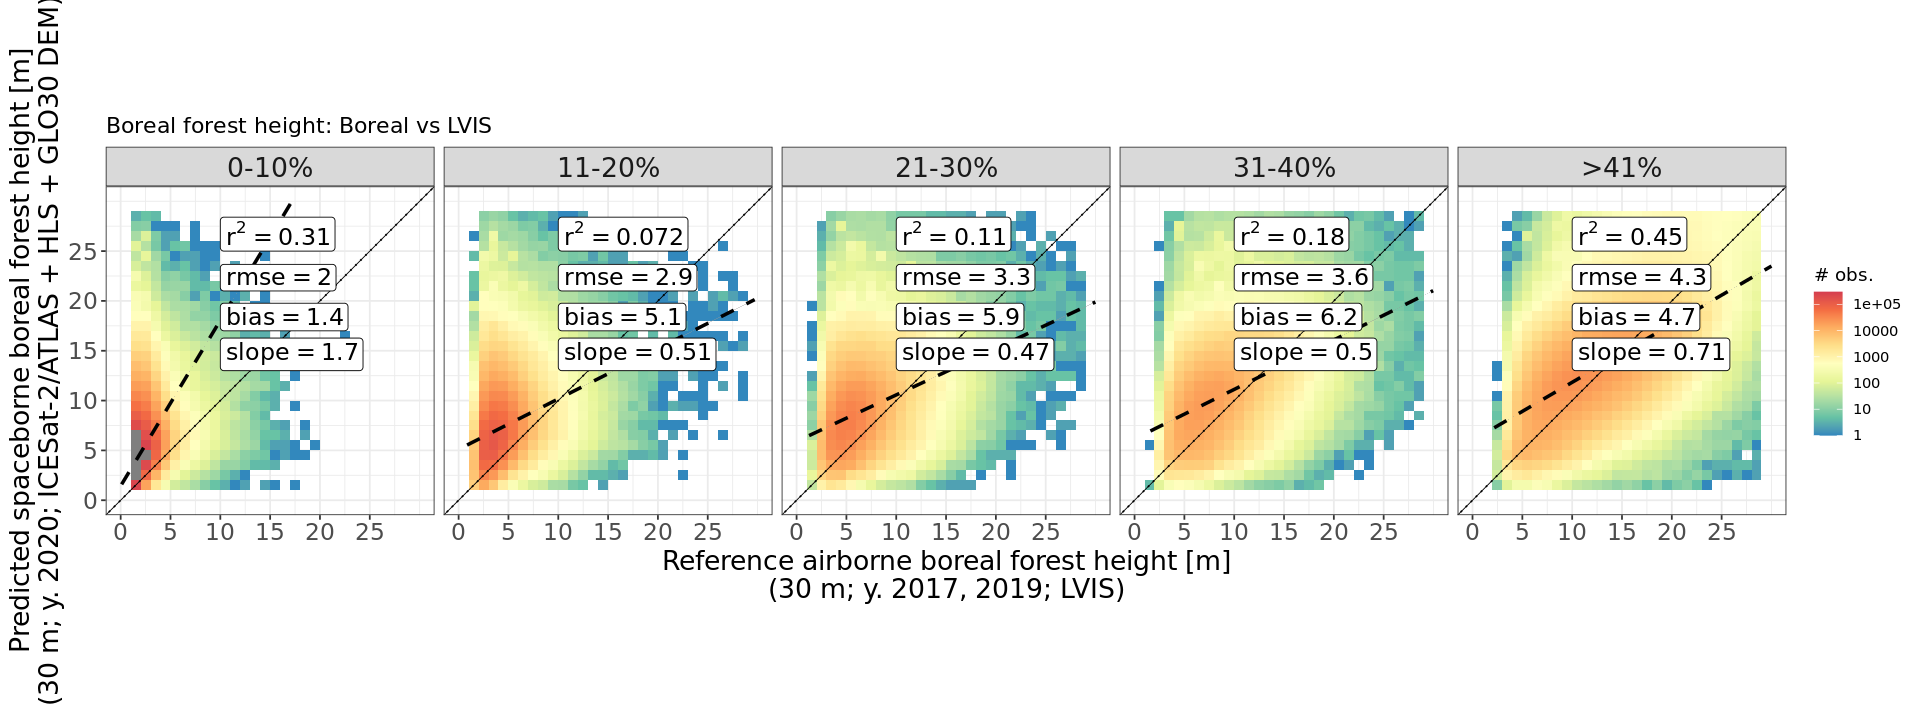

In [122]:
options(repr.plot.width = 16, repr.plot.height = 6)

ggplot(df, aes(x=LVIS.Height, y=Gridded.ATL08.Height)) +
    geom_bin2d() +
    geom_abline(linetype = 'dotted') +
    #scale_fill_viridis(trans = 'log', breaks = c(1e0, 1e1, 1e2, 1e3, 1e4,1e5), option = 'plasma') + 
    val_plot_geom_list +
    facet_grid(".~cover_class") +
    theme_bw() +
    theme(
        strip.text = element_text(size=16),
        axis.text = element_text(size=14),
        axis.title = element_text(size=16)
        ) +
    labs(y = 'Predicted spaceborne boreal forest height [m]\n(30 m; y. 2020; ICESat-2/ATLAS + HLS + GLO30 DEM)',
         x = 'Reference airborne boreal forest height [m]\n(30 m; y. 2017, 2019; LVIS)')

In [114]:
options(repr.plot.width = 8, repr.plot.height = 5)

p_box = ggplot(df, aes(y=residuals, x=cover_class, fill=slope_class)) +
    #geom_violin() +
    geom_boxplot(outlier.shape = NA) +
    geom_hline(aes(yintercept=0), linetype='dotted') +
    scale_fill_viridis_d(option='cividis') + 
    #facet_grid("slope_class~.") +
    coord_cartesian(ylim=c(-10,10)) +
    theme_bw() +
    theme(
        strip.text = element_text(size=16),
        axis.text = element_text(size=16),
        axis.text.x = element_text(angle=0),
        axis.title = element_text(size=16)
        ) +
    labs(y = 'Residuals of predicted boreal forest height [m]\n(30 m; y. 2020; ICESat-2/ATLAS + HLS + GLO30 DEM)', 
         x = 'Reference tree canopy cover class\n(30 m; y. 2017, 2019; LVIS)')

p_hist = ggplot(df, aes(x=LVIS.Cover/100)) +
    geom_histogram()+
    theme_bw() +
    theme(
        strip.text = element_text(size=16),
        axis.text = element_text(size=16),
        axis.text.x = element_text(angle=0),
        axis.title = element_text(size=16)
        ) +
    labs(
         x = 'Reference tree canopy cover class\n(30 m; y. 2017, 2019; LVIS)')

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


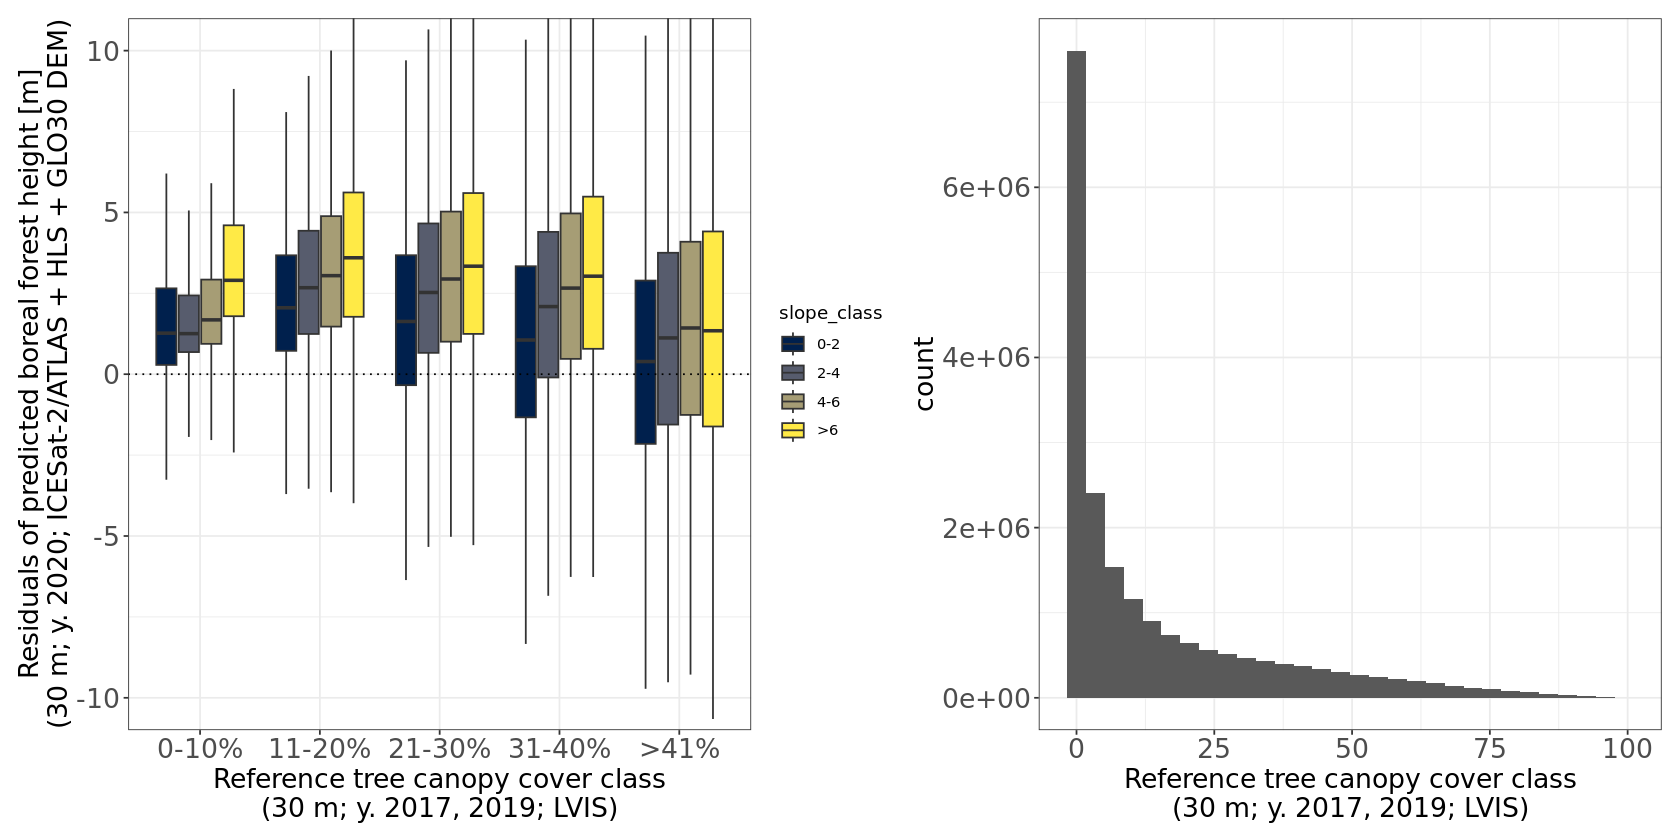

In [117]:
options(repr.plot.width = 14, repr.plot.height = 7)

p_box + p_hist

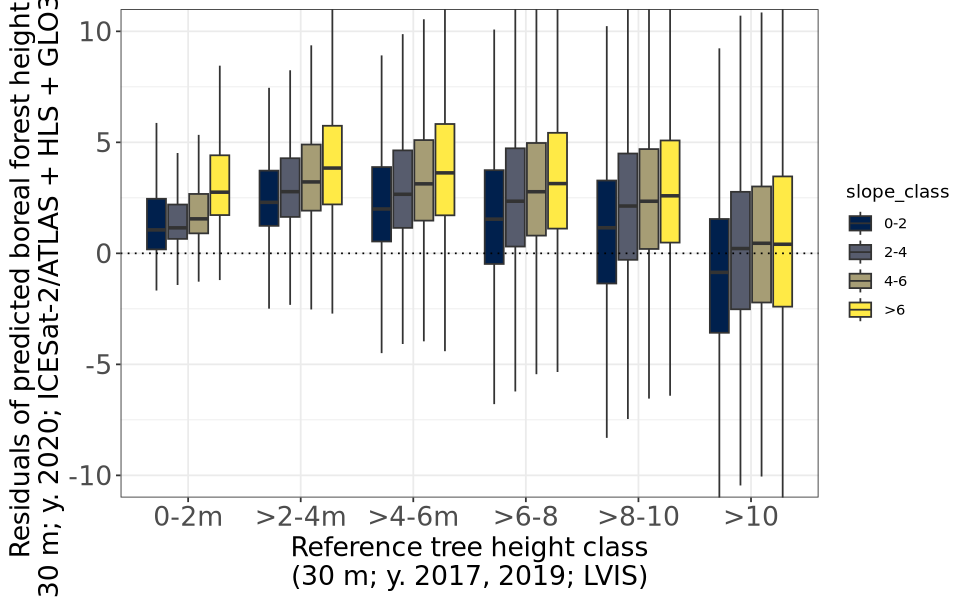

In [20]:
options(repr.plot.width = 8, repr.plot.height = 5)

p_box = ggplot(df, aes(y=residuals, x=height_class, fill=slope_class)) +
    #geom_violin() +
    geom_boxplot(outlier.shape = NA) +
    geom_hline(aes(yintercept=0), linetype='dotted') +
    scale_fill_viridis_d(option='cividis') + 
    #facet_grid("slope_class~.") +
    coord_cartesian(ylim=c(-10,10)) +
    theme_bw() +
    theme(
        strip.text = element_text(size=16),
        axis.text = element_text(size=16),
        axis.text.x = element_text(angle=0),
        axis.title = element_text(size=16)
        ) +
    labs(y = 'Residuals of predicted boreal forest height [m]\n(30 m; y. 2020; ICESat-2/ATLAS + HLS + GLO30 DEM)', 
         x = 'Reference tree height class\n(30 m; y. 2017, 2019; LVIS)')

p_box

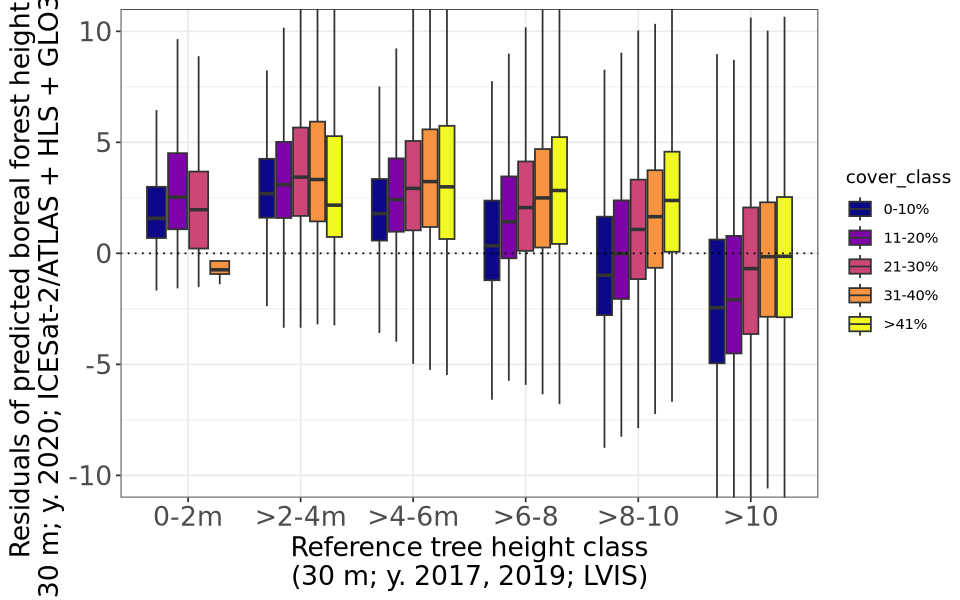

In [21]:
options(repr.plot.width = 8, repr.plot.height = 5)

p_box = ggplot(df, aes(y=residuals, x=height_class, fill=cover_class)) +
    #geom_violin() +
    geom_boxplot(outlier.shape = NA) +
    geom_hline(aes(yintercept=0), linetype='dotted') +
    scale_fill_viridis_d(option='plasma') + 
    #facet_grid("slope_class~.") +
    coord_cartesian(ylim=c(-10,10)) +
    theme_bw() +
    theme(
        strip.text = element_text(size=16),
        axis.text = element_text(size=16),
        axis.text.x = element_text(angle=0),
        axis.title = element_text(size=16)
        ) +
    labs(y = 'Residuals of predicted boreal forest height [m]\n(30 m; y. 2020; ICESat-2/ATLAS + HLS + GLO30 DEM)', 
         x = 'Reference tree height class\n(30 m; y. 2017, 2019; LVIS)')

p_box